# Uber Ride Analysis and Cancellation Prediction

Este notebook apresenta um fluxo completo de análise exploratória de dados e modelagem inicial para previsão de cancelamento de corridas em uma plataforma de transporte por aplicativo.

## Etapas
- Carregamento e inspeção dos dados
- Limpeza e padronização
- Engenharia de atributos
- Análise exploratória
- Preparação para Machine Learning
- Treinamento e avaliação de modelo


In [39]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 1. Carregamento dos dados

Ajuste o nome do arquivo abaixo conforme o nome do seu dataset.

In [40]:
file_path = 'ncr_ride_bookings.csv'
df = pd.read_csv(file_path)

df.head()


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


## 2. Entendimento inicial dos dados

In [41]:
print('Dimensão do dataset:', df.shape)
print('\nInformações gerais:')
df.info()

print('\nValores ausentes por coluna:')
display(df.isnull().sum())

print('\nResumo estatístico:')
display(df.describe(include='all'))


Dimensão do dataset: (150000, 21)

Informações gerais:
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64


Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64


Resumo estatístico:


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,150000,139500.000000,102000.000000,10500.0,10500,27000.0,27000,9000.0,9000,102000.000000,102000.000000,93000.000000,93000.000000,102000
unique,365,62910,148767,5,148788,7,176,176,NaN,NaN,NaN,5,NaN,4,NaN,3,NaN,NaN,NaN,NaN,5
top,2024-11-16,17:44:57,"""CNR7908610""",Completed,"""CID6468528""",Auto,Khandsa,Ashram,NaN,NaN,NaN,Wrong Address,NaN,Customer related issue,NaN,Customer Demand,NaN,NaN,NaN,NaN,UPI
freq,462,16,3,93000,3,37419,949,936,NaN,NaN,NaN,2362,NaN,6837,NaN,3040,NaN,NaN,NaN,NaN,45909
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456352,29.149636,1.0,NaN,1.0,NaN,1.0,NaN,508.295912,24.637012,4.230992,4.404584,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,0.0,NaN,0.0,NaN,0.0,NaN,395.805774,14.002138,0.436871,0.437819,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,10.000000,1.0,NaN,1.0,NaN,1.0,NaN,50.000000,1.000000,3.000000,3.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300000,21.600000,1.0,NaN,1.0,NaN,1.0,NaN,234.000000,12.460000,4.100000,4.200000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,28.800000,1.0,NaN,1.0,NaN,1.0,NaN,414.000000,23.720000,4.300000,4.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300000,36.800000,1.0,NaN,1.0,NaN,1.0,NaN,689.000000,36.820000,4.600000,4.800000,NaN


## 3. Padronização dos nomes das colunas

Este passo ajuda a evitar erros no código.

In [42]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)

print(df.columns.tolist())


['date', 'time', 'booking_id', 'booking_status', 'customer_id', 'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat', 'avg_ctat', 'cancelled_rides_by_customer', 'reason_for_cancelling_by_customer', 'cancelled_rides_by_driver', 'driver_cancellation_reason', 'incomplete_rides', 'incomplete_rides_reason', 'booking_value', 'ride_distance', 'driver_ratings', 'customer_rating', 'payment_method']


## 4. Ajuste opcional de nomes de colunas

Se o seu dataset tiver nomes um pouco diferentes, ajuste neste dicionário.
Exemplo: `booking_status`, `ride_value`, `driver_ratings`, `customer_rating`, `booking_value`, `date`, `time`, etc.

In [43]:
# Ajuste apenas se necessário
rename_map = {
    # 'booking_value': 'ride_value',
    # 'customer_ratings': 'customer_rating',
    # 'driver_ratings': 'driver_rating',
}

df = df.rename(columns=rename_map)
print(df.columns.tolist())


['date', 'time', 'booking_id', 'booking_status', 'customer_id', 'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat', 'avg_ctat', 'cancelled_rides_by_customer', 'reason_for_cancelling_by_customer', 'cancelled_rides_by_driver', 'driver_cancellation_reason', 'incomplete_rides', 'incomplete_rides_reason', 'booking_value', 'ride_distance', 'driver_ratings', 'customer_rating', 'payment_method']


## 5. Limpeza dos dados

In [44]:
# Remover duplicados
df = df.drop_duplicates().copy()

# Preencher colunas numéricas ausentes com a mediana
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Preencher colunas categóricas ausentes com 'Unknown'
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')

print('Dimensão após limpeza:', df.shape)


Dimensão após limpeza: (150000, 21)


## 6. Engenharia de atributos

Esta etapa cria variáveis úteis para análise e modelagem.

In [45]:
# Criar variável de cancelamento
# Completed = 0 | Demais status = 1
if 'booking_status' in df.columns:
    df['cancelamento'] = np.where(df['booking_status'].astype(str).str.lower() == 'completed', 0, 1)
else:
    raise ValueError("A coluna 'booking_status' não foi encontrada. Ajuste o nome da coluna.")

# Tentar criar variáveis temporais
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['dia_semana'] = df['date'].dt.day_name()
    df['mes'] = df['date'].dt.month

if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df['hora'] = df['time'].dt.hour
elif 'date' in df.columns:
    df['hora'] = df['date'].dt.hour

if 'hora' in df.columns:
    df['horario_pico'] = np.where(df['hora'].between(7, 9) | df['hora'].between(17, 20), 1, 0)
    df['is_weekend'] = np.where(df['dia_semana'].isin(['Saturday', 'Sunday']), 1, 0) if 'dia_semana' in df.columns else 0

# Criar valor por quilômetro, se houver colunas adequadas
if 'booking_value' in df.columns and 'ride_distance' in df.columns:
    df_valor = df[df['booking_value'] > 0].copy()
    df_valor['valor_por_km'] = df_valor['booking_value'] / (df_valor['ride_distance'] + 0.01)
elif 'ride_value' in df.columns and 'distance' in df.columns:
    df_valor = df[df['ride_value'] > 0].copy()
    df_valor['valor_por_km'] = df_valor['ride_value'] / (df_valor['distance'] + 0.01)
else:
    df_valor = df.copy()

df.head()


,date,time,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,cancelamento,dia_semana,mes,hora,horario_pico,is_weekend
0,2024-03-23,2026-03-23 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,8.3,28.8,1.0,Unknown,1.0,Unknown,1.0,Unknown,414.0,23.72,4.3,4.5,Unknown,1,Saturday,3,12,0,1
1,2024-11-29,2026-03-23 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,1.0,Unknown,1.0,Unknown,1.0,Vehicle Breakdown,237.0,5.73,4.3,4.5,UPI,1,Friday,11,18,1,0
2,2024-08-23,2026-03-23 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,1.0,Unknown,1.0,Unknown,1.0,Unknown,627.0,13.58,4.9,4.9,Debit Card,0,Friday,8,8,1,0
3,2024-10-21,2026-03-23 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,1.0,Unknown,1.0,Unknown,1.0,Unknown,416.0,34.02,4.6,5.0,UPI,0,Monday,10,17,1,0
4,2024-09-16,2026-03-23 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,1.0,Unknown,1.0,Unknown,1.0,Unknown,737.0,48.21,4.1,4.3,UPI,0,Monday,9,22,0,0


## 7. Análise exploratória dos dados (EDA)

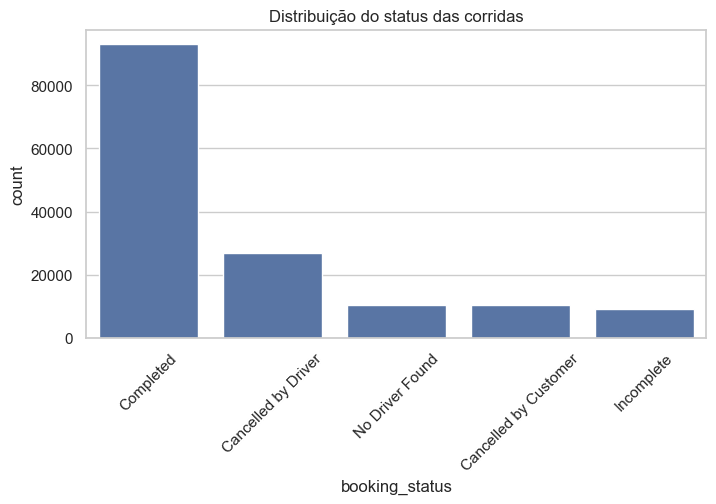

In [46]:
# Distribuição do status da corrida
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='booking_status', order=df['booking_status'].value_counts().index)
plt.title('Distribuição do status das corridas')
plt.xticks(rotation=45)
plt.show()


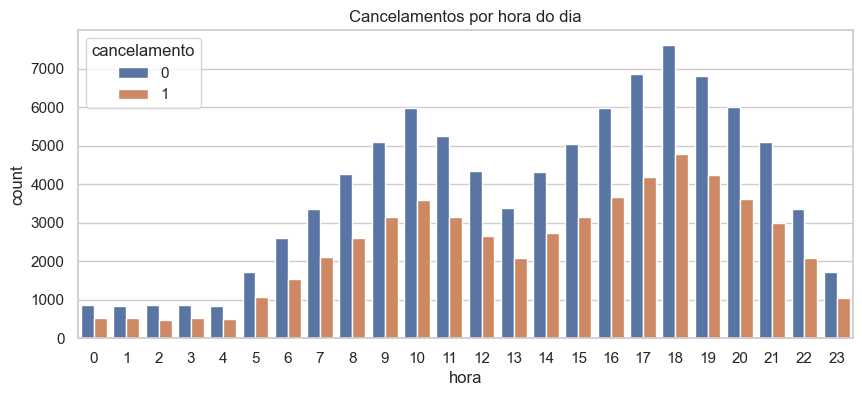

In [47]:
# Cancelamento por horário, se existir a coluna 'hora'
if 'hora' in df.columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x='hora', hue='cancelamento')
    plt.title('Cancelamentos por hora do dia')
    plt.show()


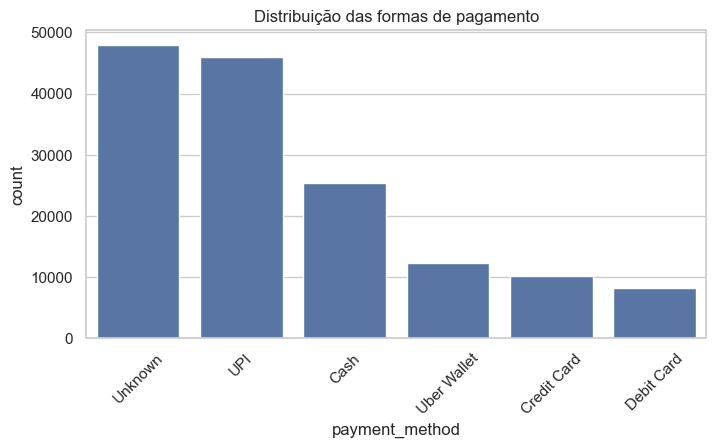

In [48]:
# Forma de pagamento mais utilizada
payment_col = None
for col in ['payment_method', 'payment_type']:
    if col in df.columns:
        payment_col = col
        break

if payment_col:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=payment_col, order=df[payment_col].value_counts().index)
    plt.title('Distribuição das formas de pagamento')
    plt.xticks(rotation=45)
    plt.show()


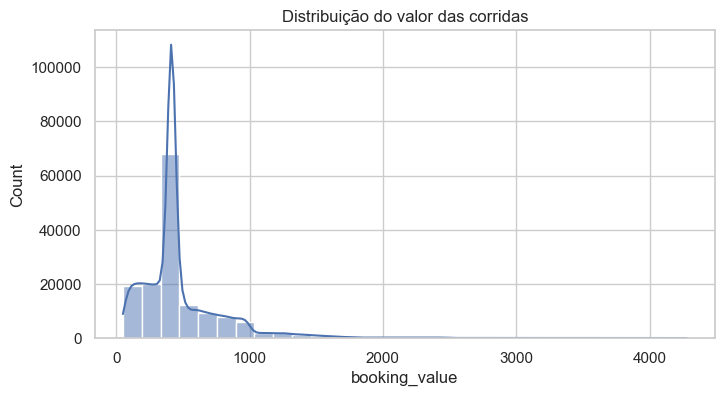

In [49]:
# Distribuição do valor da corrida
value_col = None
for col in ['booking_value', 'ride_value']:
    if col in df_valor.columns:
        value_col = col
        break

if value_col:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_valor[value_col], bins=30, kde=True)
    plt.title('Distribuição do valor das corridas')
    plt.show()


## 8. Preparação para Machine Learning

Nesta etapa, vamos selecionar algumas variáveis e treinar um modelo inicial para previsão de cancelamento.

In [50]:
# Seleção de colunas candidatas
candidate_features = []
for col in ['hora', 'horario_pico', 'ride_distance', 'distance', 'booking_value', 'ride_value', 'valor_por_km', 'customer_rating', 'driver_rating', 'customer_ratings', 'driver_ratings', 'is_weekend']:
    if col in df_valor.columns:
        candidate_features.append(col)
    elif col in df.columns:
        candidate_features.append(col)

candidate_features = list(dict.fromkeys(candidate_features))
print('Features candidatas:', candidate_features)


Features candidatas: ['hora', 'horario_pico', 'ride_distance', 'booking_value', 'valor_por_km', 'customer_rating', 'driver_ratings', 'is_weekend']


In [51]:
# Base para modelagem
model_df = df.copy()

# Se valor_por_km existir em df_valor, trazer para model_df
if 'valor_por_km' in df_valor.columns and 'booking_id' in df_valor.columns:
    model_df = model_df.merge(
        df_valor[['booking_id', 'valor_por_km']],
        on='booking_id',
        how='left'
    )

print(model_df.columns)

# Codificar colunas categóricas simples, se existirem
label_cols = []
for col in ['vehicle_type', 'payment_method', 'payment_type', 'pickup_location']:
    if col in model_df.columns:
        label_cols.append(col)

le_dict = {}
for col in label_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    le_dict[col] = le

for col in label_cols:
    if col not in candidate_features:
        candidate_features.append(col)

# Manter apenas as features que realmente existem
candidate_features = [col for col in candidate_features if col in model_df.columns]

X = model_df[candidate_features].copy()
y = model_df['cancelamento'].copy()

print('Features finais:', candidate_features)
print('Formato de X:', X.shape)
print('Formato de y:', y.shape)


Index(['date', 'time', 'booking_id', 'booking_status', 'customer_id',
       'vehicle_type', 'pickup_location', 'drop_location', 'avg_vtat',
       'avg_ctat', 'cancelled_rides_by_customer',
       'reason_for_cancelling_by_customer', 'cancelled_rides_by_driver',
       'driver_cancellation_reason', 'incomplete_rides',
       'incomplete_rides_reason', 'booking_value', 'ride_distance',
       'driver_ratings', 'customer_rating', 'payment_method', 'cancelamento',
       'dia_semana', 'mes', 'hora', 'horario_pico', 'is_weekend',
       'valor_por_km'],
      dtype='str')
Features finais: ['hora', 'horario_pico', 'ride_distance', 'booking_value', 'valor_por_km', 'customer_rating', 'driver_ratings', 'is_weekend', 'vehicle_type', 'payment_method', 'pickup_location']
Formato de X: (152484, 11)
Formato de y: (152484,)


## 9. Divisão treino e teste

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)


Treino: (121987, 11)
Teste: (30497, 11)


## 10. Treinamento do modelo

In [53]:
model = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=8)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


## 11. Avaliação do modelo

In [54]:
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('\nMatriz de confusão:')
print(confusion_matrix(y_test, y_pred))
print('\nRelatório de classificação:')
print(classification_report(y_test, y_pred))


Accuracy: 0.9976

Matriz de confusão:
[[18831    72]
 [    0 11594]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18903
           1       0.99      1.00      1.00     11594

    accuracy                           1.00     30497
   macro avg       1.00      1.00      1.00     30497
weighted avg       1.00      1.00      1.00     30497



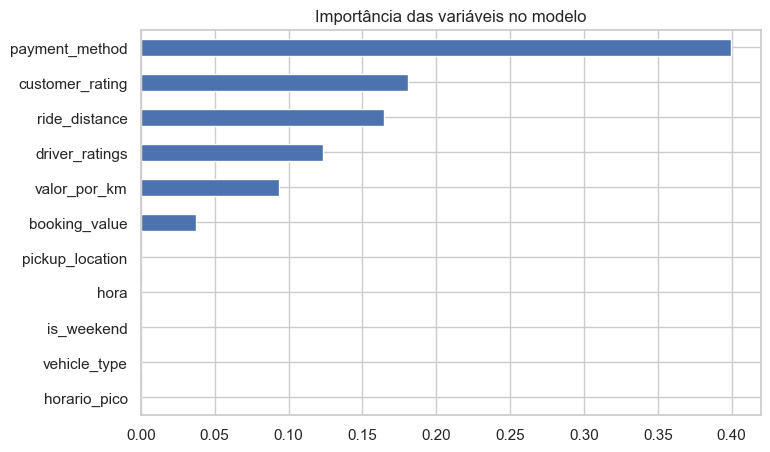

In [55]:
# Importância das variáveis
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('Importância das variáveis no modelo')
plt.show()


## 12. Conclusões

- A análise exploratória mostrou padrões relevantes de comportamento dos usuários ao longo do tempo.
- Variáveis temporais e operacionais ajudam a explicar parte do comportamento de cancelamento.
- O modelo inicial de Random Forest demonstrou potencial para apoiar previsões de cancelamento.
- Próximos passos incluem testar novos atributos, ajustar hiperparâmetros e comparar diferentes modelos.
